# 09 - Severity Scoring

This notebook implements the severity scoring framework from the project PDF.

Severity scoring turns AI predictions into quality-control decisions.

## Severity Formula

From the PDF:

```text
Severity Score =
Size x 30%
Location x 25%
Defect Type x 25%
Confidence x 20%
```

Severity levels:

- Critical: 80-100
- High: 60-79
- Medium: 40-59
- Low: 0-39

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml.severity import (
    calculate_severity,
    calculate_severity_from_prediction,
    score_from_confidence,
    score_from_defect_area_ratio,
    score_from_defect_type,
    score_from_location,
)

REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
CHART_DIR = PROJECT_ROOT / "outputs" / "charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai


## PDF Example

The PDF gives this example:

- Type: Surface Crack
- Size Score: 85
- Location Score: 90
- Defect Type Score: 95
- Confidence Score: 92

Expected severity score: around 88, Critical.

In [2]:
pdf_example = calculate_severity(
    size_score=85,
    location_score=90,
    defect_type_score=95,
    confidence_score=92,
)

pdf_example

{'severity_score': 90.15,
 'severity_level': 'Critical',
 'pass_fail': 'Fail',
 'recommended_action': 'Reject product and trigger quality inspection workflow',
 'components': {'size_score': 85.0,
  'location_score': 90.0,
  'defect_type_score': 95.0,
  'confidence_score': 92.0}}

## Component Scoring Rules

For implementation, each component needs a score between 0 and 100.

### Size Score

Computed from defect area ratio:

- 0%: 0
- less than 0.5%: 20
- less than 2%: 45
- less than 5%: 70
- 5% or more: 90

### Location Score

- critical area: 90
- central region heuristic: 65
- non-critical area: 35

### Defect Type Score

- `good`: 0
- `contamination`: 55
- `broken_small`: 75
- `broken_large`: 95

### Confidence Score

Model confidence normalized to 0-100.

## Size Score Examples

In [3]:
area_examples = [0.0, 0.002, 0.01, 0.035, 0.08]
size_examples_df = pd.DataFrame({
    "area_ratio": area_examples,
    "area_percent": [ratio * 100 for ratio in area_examples],
    "size_score": [score_from_defect_area_ratio(ratio) for ratio in area_examples],
})

size_examples_df

,area_ratio,area_percent,size_score
0,0.000,0.0,0
1,0.002,0.2,20
2,0.010,1.0,45
3,0.035,3.5,70
4,0.080,8.0,90


## Defect Type Score Examples

In [4]:
type_examples = ["good", "contamination", "broken_small", "broken_large"]
type_scores_df = pd.DataFrame({
    "defect_type": type_examples,
    "defect_type_score": [score_from_defect_type(label) for label in type_examples],
})

type_scores_df

,defect_type,defect_type_score
0,good,0.0
1,contamination,55.0
2,broken_small,75.0
3,broken_large,95.0


## Simulated Inspection Predictions

These examples mimic what the backend will receive from the anomaly detector and classifier.

In [5]:
inspection_examples = [
    {
        "inspection_id": "INS-001",
        "defect_type": "good",
        "confidence": 0.98,
        "area_ratio": 0.0,
        "is_critical_location": False,
        "defect_center_y_ratio": None,
    },
    {
        "inspection_id": "INS-002",
        "defect_type": "contamination",
        "confidence": 0.89,
        "area_ratio": 0.012,
        "is_critical_location": False,
        "defect_center_y_ratio": 0.40,
    },
    {
        "inspection_id": "INS-003",
        "defect_type": "broken_small",
        "confidence": 0.92,
        "area_ratio": 0.031,
        "is_critical_location": True,
        "defect_center_y_ratio": 0.50,
    },
    {
        "inspection_id": "INS-004",
        "defect_type": "broken_large",
        "confidence": 0.96,
        "area_ratio": 0.085,
        "is_critical_location": True,
        "defect_center_y_ratio": 0.52,
    },
]

inspection_examples

[{'inspection_id': 'INS-001',
  'defect_type': 'good',
  'confidence': 0.98,
  'area_ratio': 0.0,
  'is_critical_location': False,
  'defect_center_y_ratio': None},
 {'inspection_id': 'INS-002',
  'defect_type': 'contamination',
  'confidence': 0.89,
  'area_ratio': 0.012,
  'is_critical_location': False,
  'defect_center_y_ratio': 0.4},
 {'inspection_id': 'INS-003',
  'defect_type': 'broken_small',
  'confidence': 0.92,
  'area_ratio': 0.031,
  'is_critical_location': True,
  'defect_center_y_ratio': 0.5},
 {'inspection_id': 'INS-004',
  'defect_type': 'broken_large',
  'confidence': 0.96,
  'area_ratio': 0.085,
  'is_critical_location': True,
  'defect_center_y_ratio': 0.52}]

## Calculate Severity For Each Inspection

In [6]:
severity_rows = []

for item in inspection_examples:
    severity = calculate_severity_from_prediction(
        defect_type=item["defect_type"],
        confidence=item["confidence"],
        area_ratio=item["area_ratio"],
        is_critical_location=item["is_critical_location"],
        defect_center_y_ratio=item["defect_center_y_ratio"],
    )
    row = {**item, **severity, **severity["components"]}
    row.pop("components")
    severity_rows.append(row)

severity_df = pd.DataFrame(severity_rows)
severity_df

,inspection_id,defect_type,confidence,area_ratio,is_critical_location,defect_center_y_ratio,severity_score,severity_level,pass_fail,recommended_action,size_score,location_score,defect_type_score,confidence_score
0,INS-001,good,0.98,0.000,False,NaN,28.35,Low,Pass,Product generally acceptable,0.0,35.0,0.0,98.0
1,INS-002,contamination,0.89,0.012,False,0.40,61.30,High,Fail,Repair or rework recommended,45.0,65.0,55.0,89.0
2,INS-003,broken_small,0.92,0.031,True,0.50,80.65,Critical,Fail,Reject product and trigger quality inspection ...,70.0,90.0,75.0,92.0
3,INS-004,broken_large,0.96,0.085,True,0.52,92.45,Critical,Fail,Reject product and trigger quality inspection ...,90.0,90.0,95.0,96.0


## Visualize Severity Scores

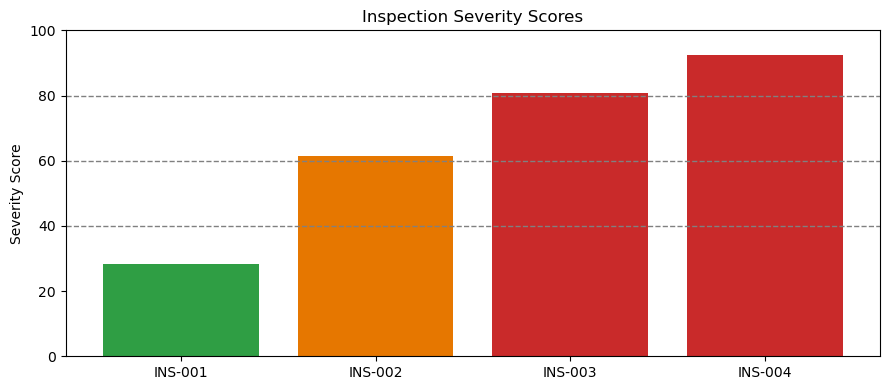

Saved chart: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\charts\severity_scores.png


In [7]:
level_colors = {
    "Low": "#2f9e44",
    "Medium": "#f08c00",
    "High": "#e67700",
    "Critical": "#c92a2a",
}

colors = [level_colors[level] for level in severity_df["severity_level"]]

plt.figure(figsize=(9, 4))
plt.bar(severity_df["inspection_id"], severity_df["severity_score"], color=colors)
plt.axhline(40, linestyle="--", color="gray", linewidth=1)
plt.axhline(60, linestyle="--", color="gray", linewidth=1)
plt.axhline(80, linestyle="--", color="gray", linewidth=1)
plt.ylim(0, 100)
plt.ylabel("Severity Score")
plt.title("Inspection Severity Scores")
plt.tight_layout()

severity_chart_path = CHART_DIR / "severity_scores.png"
plt.savefig(severity_chart_path, dpi=160)
plt.show()

print("Saved chart:", severity_chart_path)

## Component Contribution

This shows how much each component contributes to the final severity score.

In [8]:
component_df = severity_df[[
    "inspection_id",
    "size_score",
    "location_score",
    "defect_type_score",
    "confidence_score",
]].copy()

weighted_df = component_df.copy()
weighted_df["size_score"] *= 0.30
weighted_df["location_score"] *= 0.25
weighted_df["defect_type_score"] *= 0.25
weighted_df["confidence_score"] *= 0.20

weighted_df

,inspection_id,size_score,location_score,defect_type_score,confidence_score
0,INS-001,0.0,8.75,0.00,19.6
1,INS-002,13.5,16.25,13.75,17.8
2,INS-003,21.0,22.50,18.75,18.4
3,INS-004,27.0,22.50,23.75,19.2


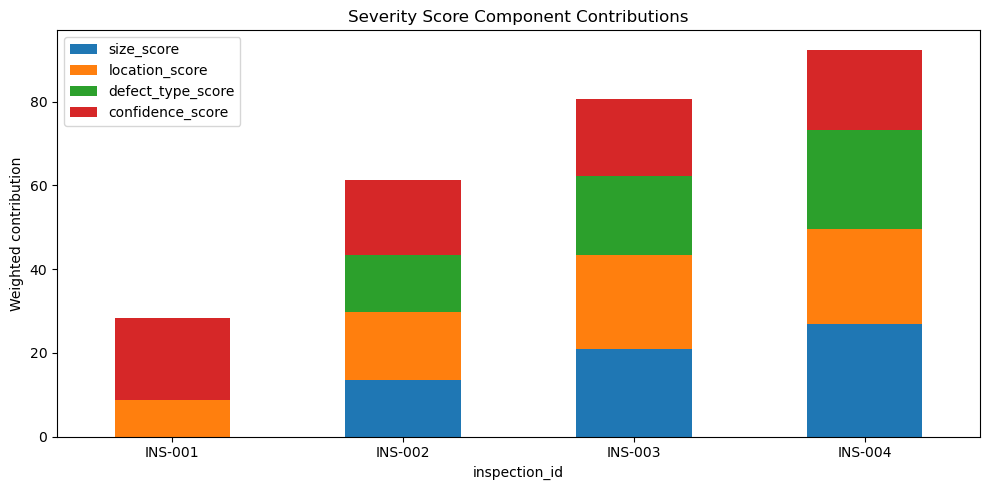

Saved chart: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\charts\severity_component_contributions.png


In [9]:
plot_df = weighted_df.set_index("inspection_id")

plot_df.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.ylabel("Weighted contribution")
plt.title("Severity Score Component Contributions")
plt.xticks(rotation=0)
plt.tight_layout()

component_chart_path = CHART_DIR / "severity_component_contributions.png"
plt.savefig(component_chart_path, dpi=160)
plt.show()

print("Saved chart:", component_chart_path)

## Save Severity Outputs

These files will be used in the final report and later backend implementation.

In [10]:
severity_csv = REPORT_DIR / "severity_scoring_examples.csv"
severity_json = REPORT_DIR / "severity_scoring_examples.json"

severity_df.to_csv(severity_csv, index=False)

with severity_json.open("w", encoding="utf-8") as file:
    json.dump(severity_rows, file, indent=2)

print("Saved CSV:", severity_csv)
print("Saved JSON:", severity_json)

Saved CSV: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\severity_scoring_examples.csv
Saved JSON: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\severity_scoring_examples.json


## Backend Output Shape

The FastAPI backend can return a result like this after image inspection.

In [11]:
backend_response_example = {
    "inspection_id": "INS-004",
    "prediction": "defective",
    "defect_type": "broken_large",
    "confidence": 0.96,
    "severity": calculate_severity_from_prediction(
        defect_type="broken_large",
        confidence=0.96,
        area_ratio=0.085,
        is_critical_location=True,
        defect_center_y_ratio=0.52,
    ),
    "image_url": "https://cloudinary.example/original.png",
    "heatmap_url": "https://cloudinary.example/heatmap.png",
}

backend_response_example

{'inspection_id': 'INS-004',
 'prediction': 'defective',
 'defect_type': 'broken_large',
 'confidence': 0.96,
 'severity': {'severity_score': 92.45,
  'severity_level': 'Critical',
  'pass_fail': 'Fail',
  'recommended_action': 'Reject product and trigger quality inspection workflow',
  'components': {'size_score': 90.0,
   'location_score': 90.0,
   'defect_type_score': 95.0,
   'confidence_score': 96.0},
  'defect_type': 'broken_large',
  'confidence': 0.96,
  'area_ratio': 0.085,
  'is_critical_location': True,
  'defect_center_y_ratio': 0.52},
 'image_url': 'https://cloudinary.example/original.png',
 'heatmap_url': 'https://cloudinary.example/heatmap.png'}

## Summary

You implemented severity scoring:

- size score
- location score
- defect type score
- confidence score
- final severity score
- severity level
- pass/fail/review decision
- recommended action

Next notebook: `10_model_evaluation_results.ipynb`.